In [1]:
import torch
import numpy as np

print(torch.__version__)
print(np.__version__)


2.1.0+cpu
1.26.4


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import os


In [3]:
# Base path
BASE_DIR = r"C:\Users\nshre\OneDrive\Desktop\Vision-Based-Fake-Medicine-Detection\dataset"

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [5]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(BASE_DIR, "Train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(BASE_DIR, "Val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(BASE_DIR, "Test"),
    transform=transform
)


In [6]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))


Classes: ['Fake', 'Real']
Training images: 660
Validation images: 453
Testing images: 449


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.64].


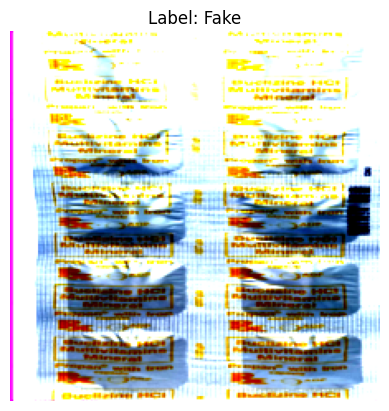

In [7]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.imshow(images[0].permute(1, 2, 0))
plt.title(f"Label: {train_dataset.classes[labels[0]]}")
plt.axis("off")
plt.show()
